In [2]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE

nltk.download('stopwords')
nltk.download('wordnet')

C:\Users\kavya\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kavya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kavya\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_excel("C:\\Users\\kavya\\Downloads\\nykaa product review.xlsx")

# print("First 5 rows:\n", df.head())
#print("\nInfo:\n")
#print(df.info())

df.head()

,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,pro_user,review_label,product_title,mrp,price,product_rating,product_rating_count,product_tags,product_url
0,781070,Olay,16752142,Worth buying 50g one,Works as it claims. Could see the difference f...,Ashton Dsouza,2021-01-23 15:17:18,5.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
1,781070,Olay,14682550,Best cream to start ur day,It does what it claims . Best thing is it smoo...,Amrit Neelam,2020-09-07 15:30:42,5.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
2,781070,Olay,15618995,perfect for summers dry for winters,I have been using this product for months now....,Sanchi Gupta,2020-11-13 12:24:14,4.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
3,781070,Olay,13474509,Not a moisturizer,"i have an oily skin, while this whip acts as a...",Ruchi Shah,2020-06-14 11:56:50,3.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
4,781070,Olay,16338982,Average,It's not that good. Please refresh try for oth...,Sukanya Sarkar,2020-12-22 15:24:35,2.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...



Missing Values:
 product_id                  0
brand_name                  0
review_id                   0
review_title                5
review_text                15
author                      0
review_date                 0
review_rating               1
is_a_buyer                  0
pro_user                    0
review_label            13035
product_title               0
mrp                         0
price                       0
product_rating              0
product_rating_count        0
product_tags            47782
product_url                 0
dtype: int64


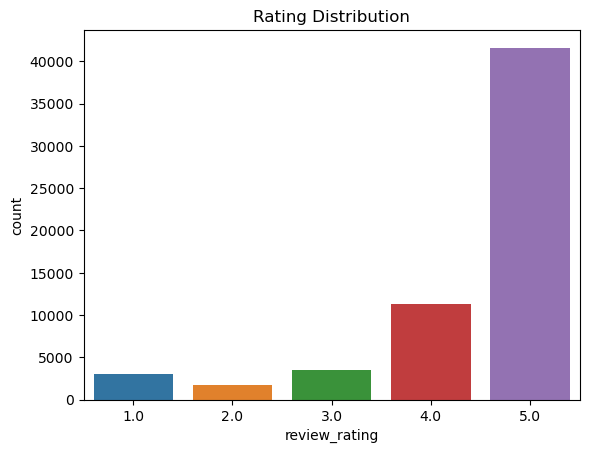

In [4]:
# ===============================
# 3. EDA
# ===============================

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Rating distribution
plt.figure()
sns.countplot(x='review_rating', data=df)
plt.title("Rating Distribution")
plt.show()

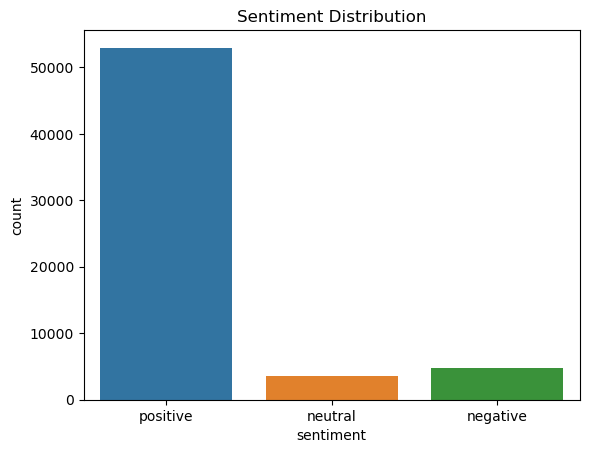

In [5]:
# Create sentiment
def get_sentiment(r):
    if r >= 4:
        return "positive"
    elif r == 3:
        return "neutral"
    else:
        return "negative"

df['sentiment'] = df['review_rating'].apply(get_sentiment)

# Sentiment distribution
plt.figure()
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


C:\Users\kavya\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


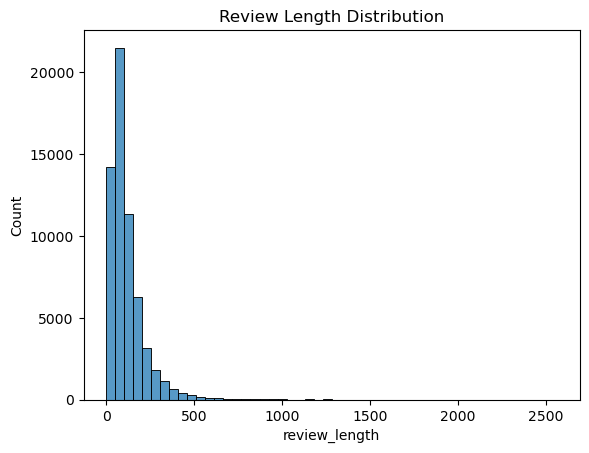


Avg Review Length:
 sentiment
negative    133.163678
neutral     132.217514
positive    114.307925
Name: review_length, dtype: float64

Top Brands:
 brand_name
Nykaa Cosmetics            17652
Kay Beauty                 13788
Lakme                       6999
Maybelline New York         6821
Herbal Essences             6197
L'Oreal Paris               4273
NYX Professional Makeup     2954
Nykaa Naturals              1426
Nivea                        774
Olay                         399
Name: count, dtype: int64


In [6]:
# Review length
df['review_text'] = df['review_text'].fillna("").astype(str)
df['review_length'] = df['review_text'].apply(len)

plt.figure()
sns.histplot(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

print("\nAvg Review Length:\n",
      df.groupby('sentiment')['review_length'].mean())

# Top brands (if exists)
if 'brand_name' in df.columns:
    print("\nTop Brands:\n", df['brand_name'].value_counts().head(10))
    

In [7]:
# ===============================
# 4. REMOVE NEUTRAL (BIAS FIX)
# ===============================
df = df[df['sentiment'] != 'neutral']

# ===============================
# 5. TEXT PREPROCESSING 
# ===============================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    
    # Handle negation (IMPORTANT)
    text = text.replace("not good", "not_good")
    text = text.replace("not bad", "not_bad")
    text = text.replace("not great", "not_great")
    text = text.replace("not worth", "not_worth")
    
    # Remove special characters
    text = re.sub(r'[^a-zA-Z_]', ' ', text)
    
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

df['clean_review'] = df['review_text'].apply(clean_text)


In [8]:
# ===============================
# 6. FEATURE ENGINEERING
# ===============================
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

# ===============================
# 7. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 8. HANDLE IMBALANCE (SMOTE)
# ===============================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


# ===============================
# 9. MODEL
# ===============================
model = LogisticRegression(max_iter=500)
model.fit(X_train_sm, y_train_sm)


# ===============================
# 10. PREDICTION
# ===============================
y_pred = model.predict(X_test)



Classification Report:

              precision    recall  f1-score   support

    negative       0.51      0.80      0.62       959
    positive       0.98      0.93      0.95     10590

    accuracy                           0.92     11549
   macro avg       0.74      0.86      0.79     11549
weighted avg       0.94      0.92      0.93     11549



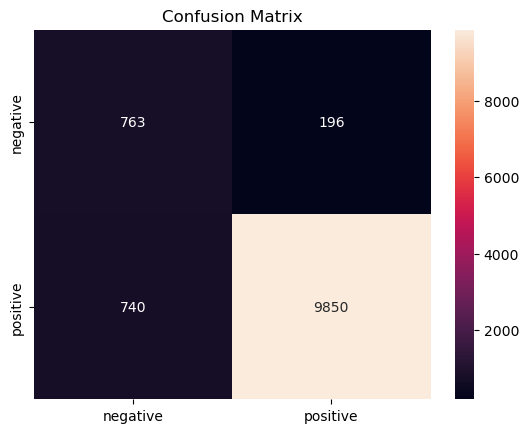


ROC-AUC Score: 0.9372833383058565

Sample Prediction: negative

Sample Prediction: negative

Sample Prediction: positive


In [11]:
# ===============================
# 11. EVALUATION
# ===============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d',
            xticklabels=['negative','positive'],
            yticklabels=['negative','positive'])
plt.title("Confusion Matrix")
plt.show()

# ROC-AUC Score
y_test_bin = y_test.map({'negative':0, 'positive':1})
y_prob = model.predict_proba(X_test)[:,1]

print("\nROC-AUC Score:", roc_auc_score(y_test_bin, y_prob))

# ===============================
# 12. SAMPLE PREDICTION 1
# ===============================
sample = ["This product is not good at all"]
sample_clean = [clean_text(sample[0])]
sample_vec = vectorizer.transform(sample_clean)

print("\nSample Prediction:", model.predict(sample_vec)[0])

# ==============================
# 13.  SAMPLE PREDICTION 2
# ==============================

sample2 = ["This product is not upto my expectations. I did not like it at all"]
sample_clean2 = [clean_text(sample2[0])]
sample_vec2 = vectorizer.transform(sample_clean2)

print("\nSample Prediction:", model.predict(sample_vec2)[0])

# ==============================
# 14.  SAMPLE PREDICTION 3
# ==============================

sample3 = ["This product is awesome. It suited me well."]
sample_clean3 = [clean_text(sample3[0])]
sample_vec3 = vectorizer.transform(sample_clean3)

print("\nSample Prediction:", model.predict(sample_vec3)[0])
